In [1]:
import pandas as pd
import numpy as np

In [4]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import pandas as pd

os.chdir(r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data")
df = pd.read_excel("GuttmacherInstituteAbortionDataByState.xlsx")

df.head()

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613


In [6]:
df.columns

Index(['U.S. State', '% change in abortion rate, 2017-2020',
       '% change in the no. of abortion clinics, 2017-2020',
       '% change in the no. of abortion providers, 2014-2017',
       '% of all U.S. abortions, by state of occurrence, 2020',
       '% of counties without a known abortion provider, 2014',
       '% of counties without a known clinic, 2020',
       '% of residents obtaining abortions who traveled out of state for care, 2020',
       '% of women aged 15-44 living in a county without a clinic, 2020',
       '% of women aged 15-44 living in a county without an abortion provider, 2014',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-17), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-19), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 18-19), by state of residence, 2017',
       'Change in the no. of abortion clinics, 2017-2020',
       'Change in th

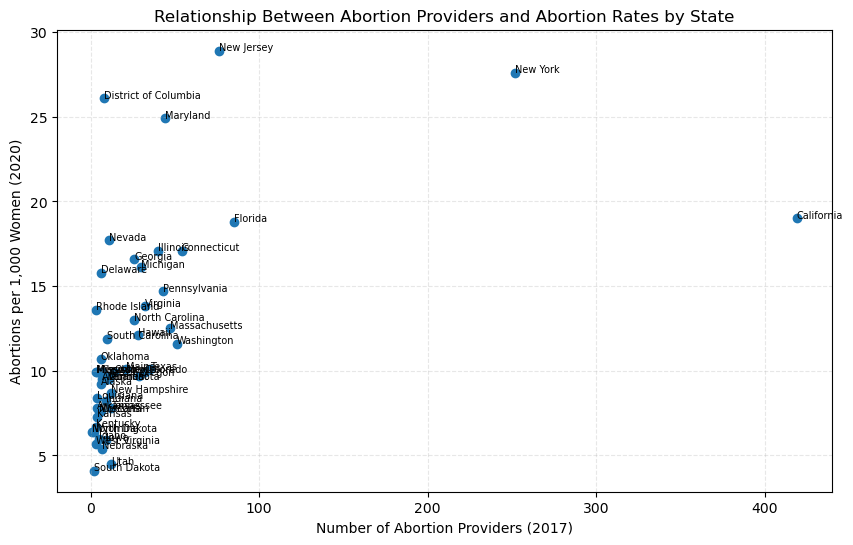

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

cols = [
    'U.S. State',
    'No. of abortion providers, 2017',
    'No. of abortions per 1,000 women aged 15–44, by state of residence, 2020'
]

df_plot = df[cols].dropna()

df_plot.columns = ['state', 'providers', 'abortion_rate']

plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot['providers'],
    df_plot['abortion_rate']
)

for i, row in df_plot.iterrows():
    plt.text(row['providers'], row['abortion_rate'], row['state'], fontsize=7)

plt.title('Relationship Between Abortion Providers and Abortion Rates by State')
plt.xlabel('Number of Abortion Providers (2017)')
plt.ylabel('Abortions per 1,000 Women (2020)')

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

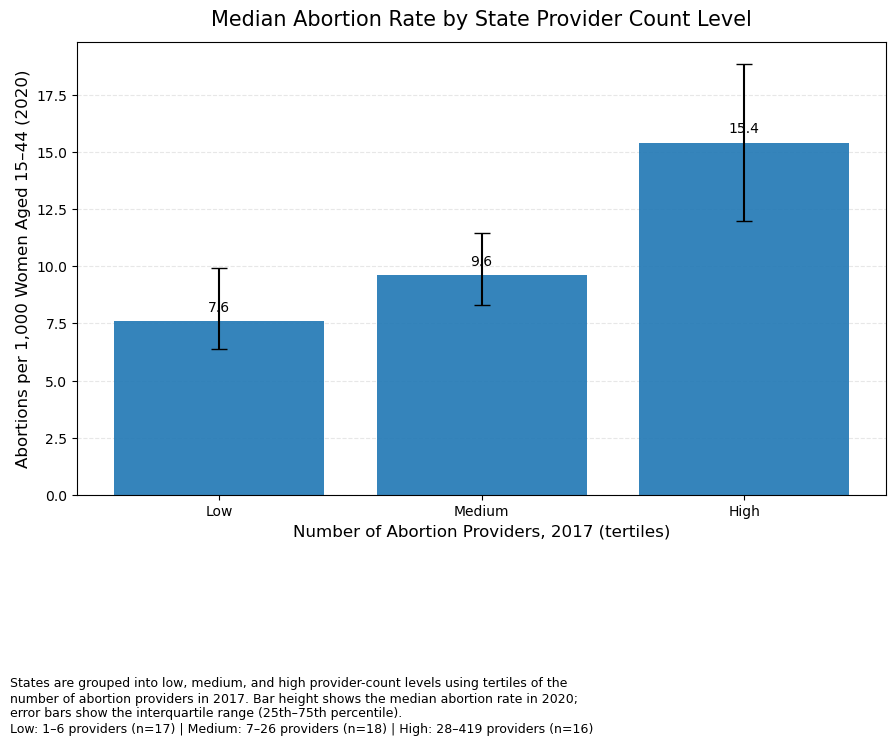

  provider_bin  median_rate      q1     q3  n_states  min_providers  \
0          Low          7.6   6.400   9.90        17              1   
1       Medium          9.6   8.325  11.45        18              7   
2         High         15.4  11.975  18.85        16             28   

   max_providers  
0              6  
1             26  
2            419  


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. read data ===
file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

# === 2. select columns ===
cols = [
    'U.S. State',
    'No. of abortion providers, 2017',
    'No. of abortions per 1,000 women aged 15–44, by state of residence, 2020'
]

df_plot = df[cols].dropna().copy()
df_plot.columns = ['state', 'providers', 'abortion_rate']

# === 3. create tertile-based categories ===
df_plot['provider_bin'] = pd.qcut(
    df_plot['providers'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# === 4. summarize with median + IQR ===
summary = (
    df_plot
    .groupby('provider_bin', observed=False)
    .agg(
        median_rate=('abortion_rate', 'median'),
        q1=('abortion_rate', lambda x: x.quantile(0.25)),
        q3=('abortion_rate', lambda x: x.quantile(0.75)),
        n_states=('state', 'count'),
        min_providers=('providers', 'min'),
        max_providers=('providers', 'max')
    )
    .reindex(['Low', 'Medium', 'High'])
    .reset_index()
)

# error bars for IQR around median
lower_err = summary['median_rate'] - summary['q1']
upper_err = summary['q3'] - summary['median_rate']
yerr = np.vstack([lower_err, upper_err])

# === 5. plot ===
fig, ax = plt.subplots(figsize=(9, 6.5))

bars = ax.bar(
    summary['provider_bin'],
    summary['median_rate'],
    yerr=yerr,
    capsize=6,
    alpha=0.9
)

# === 6. labels on bars ===
for bar, val in zip(bars, summary['median_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f'{val:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# === 7. titles and labels ===
ax.set_title(
    'Median Abortion Rate by State Provider Count Level',
    fontsize=15,
    pad=12
)

ax.set_xlabel('Number of Abortion Providers, 2017 (tertiles)', fontsize=12)
ax.set_ylabel('Abortions per 1,000 Women Aged 15–44 (2020)', fontsize=12)

# === 8. grid ===
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# === 9. build explanatory note ===
group_lines = []
for _, row in summary.iterrows():
    group_lines.append(
        f"{row['provider_bin']}: {int(row['min_providers'])}–{int(row['max_providers'])} providers "
        f"(n={int(row['n_states'])})"
    )

note_text = (
    "States are grouped into low, medium, and high provider-count levels using tertiles of the\n"
    "number of abortion providers in 2017. Bar height shows the median abortion rate in 2020;\n"
    "error bars show the interquartile range (25th–75th percentile).\n"
    + " | ".join(group_lines)
)

fig.text(
    0.01, -0.05,
    note_text,
    ha='left',
    va='top',
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.23)
plt.show()

# === 10. optional: inspect summary table ===
print(summary)

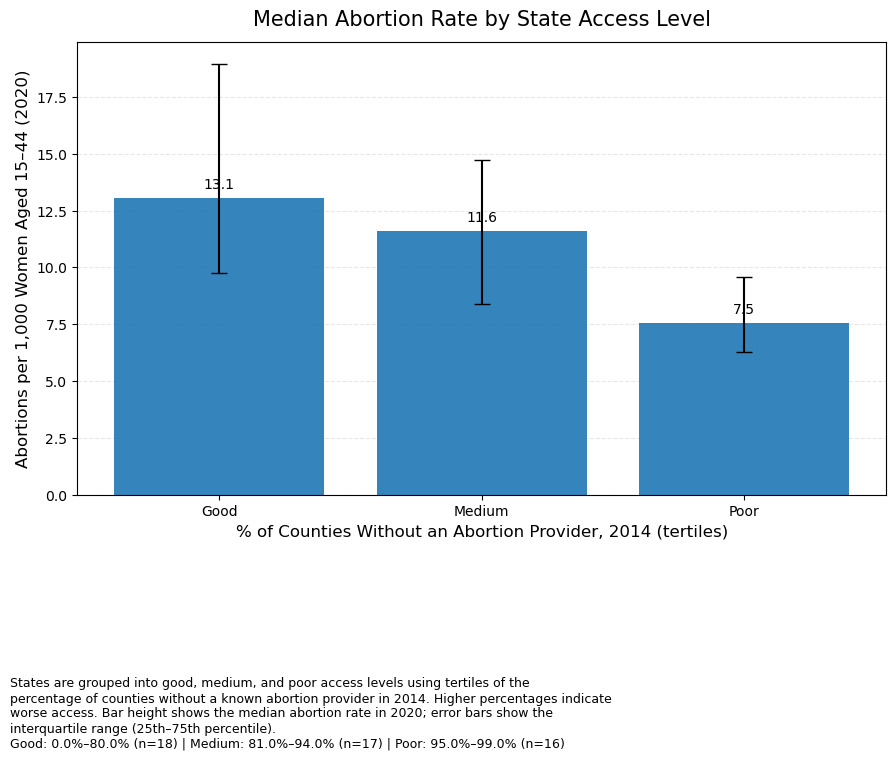

  access_bin  median_rate    q1     q3  n_states  min_pct  max_pct
0       Good        13.05  9.75  18.95        18        0       80
1     Medium        11.60  8.40  14.70        17       81       94
2       Poor         7.55  6.30   9.60        16       95       99


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. read data ===
file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

# === 2. select columns ===
cols = [
    'U.S. State',
    '% of counties without a known abortion provider, 2014',
    'No. of abortions per 1,000 women aged 15–44, by state of residence, 2020'
]

df_plot = df[cols].dropna().copy()
df_plot.columns = ['state', 'no_provider_pct', 'abortion_rate']

# === 3. create tertile-based access categories ===
# Higher % without provider = worse access
df_plot['access_bin'] = pd.qcut(
    df_plot['no_provider_pct'],
    q=3,
    labels=['Good', 'Medium', 'Poor']
)

# === 4. summarize with median + IQR ===
summary = (
    df_plot
    .groupby('access_bin', observed=False)
    .agg(
        median_rate=('abortion_rate', 'median'),
        q1=('abortion_rate', lambda x: x.quantile(0.25)),
        q3=('abortion_rate', lambda x: x.quantile(0.75)),
        n_states=('state', 'count'),
        min_pct=('no_provider_pct', 'min'),
        max_pct=('no_provider_pct', 'max')
    )
    .reindex(['Good', 'Medium', 'Poor'])
    .reset_index()
)

# === 5. error bars = IQR around median ===
lower_err = summary['median_rate'] - summary['q1']
upper_err = summary['q3'] - summary['median_rate']
yerr = np.vstack([lower_err, upper_err])

# === 6. plot ===
fig, ax = plt.subplots(figsize=(9, 6.5))

bars = ax.bar(
    summary['access_bin'],
    summary['median_rate'],
    yerr=yerr,
    capsize=6,
    alpha=0.9
)

# === 7. value labels ===
for bar, val in zip(bars, summary['median_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f'{val:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# === 8. titles and labels ===
ax.set_title(
    'Median Abortion Rate by State Access Level',
    fontsize=15,
    pad=12
)
ax.set_xlabel(
    '% of Counties Without an Abortion Provider, 2014 (tertiles)',
    fontsize=12
)
ax.set_ylabel(
    'Abortions per 1,000 Women Aged 15–44 (2020)',
    fontsize=12
)

# === 9. grid ===
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# === 10. note ===
group_lines = []
for _, row in summary.iterrows():
    group_lines.append(
        f"{row['access_bin']}: {row['min_pct']:.1f}%–{row['max_pct']:.1f}% "
        f"(n={int(row['n_states'])})"
    )

note_text = (
    "States are grouped into good, medium, and poor access levels using tertiles of the\n"
    "percentage of counties without a known abortion provider in 2014. Higher percentages indicate\n"
    "worse access. Bar height shows the median abortion rate in 2020; error bars show the\n"
    "interquartile range (25th–75th percentile).\n"
    + " | ".join(group_lines)
)

fig.text(
    0.01, -0.05,
    note_text,
    ha='left',
    va='top',
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.23)
plt.show()

# === 11. optional summary table ===
print(summary)

In [20]:
import pandas as pd

# === read data ===
file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

# === select columns ===
df_plot = df[[
    'U.S. State',
    'No. of abortion providers, 2017',
    'No. of abortions per 1,000 women aged 15–44, by state of residence, 2020'
]].dropna().copy()

df_plot.columns = ['state', 'providers', 'abortion_rate']

# === get medians ===
provider_median = df_plot['providers'].median()
rate_median = df_plot['abortion_rate'].median()

# === classify each state ===
results = []

for _, row in df_plot.iterrows():
    state = row['state']
    providers = row['providers']
    rate = row['abortion_rate']
    
    if (providers > provider_median and rate < rate_median) or \
       (providers < provider_median and rate > rate_median):
        label = 'Counterexample'
    else:
        label = 'Follows Trend'
    
    results.append((state, providers, rate, label))

# === convert to DataFrame ===
result_df = pd.DataFrame(results, columns=['State', 'Providers', 'Abortion Rate', 'Pattern'])

# === sort to see counterexamples first ===
result_df = result_df.sort_values(by='Pattern')

print(result_df)

                   State  Providers  Abortion Rate         Pattern
39          Rhode Island          3           13.6  Counterexample
29         New Hampshire         12            8.7  Counterexample
44                  Utah         12            4.5  Counterexample
7               Delaware          6           15.8  Counterexample
8   District of Columbia          8           26.1  Counterexample
42             Tennessee         12            7.8  Counterexample
40        South Carolina         10           11.9  Counterexample
37                Oregon         29            9.7  Counterexample
36              Oklahoma          6           10.7  Counterexample
28                Nevada         11           17.7   Follows Trend
30            New Jersey         76           28.9   Follows Trend
31            New Mexico          7            9.9   Follows Trend
32              New York        252           27.6   Follows Trend
33        North Carolina         26           13.0   Follows T

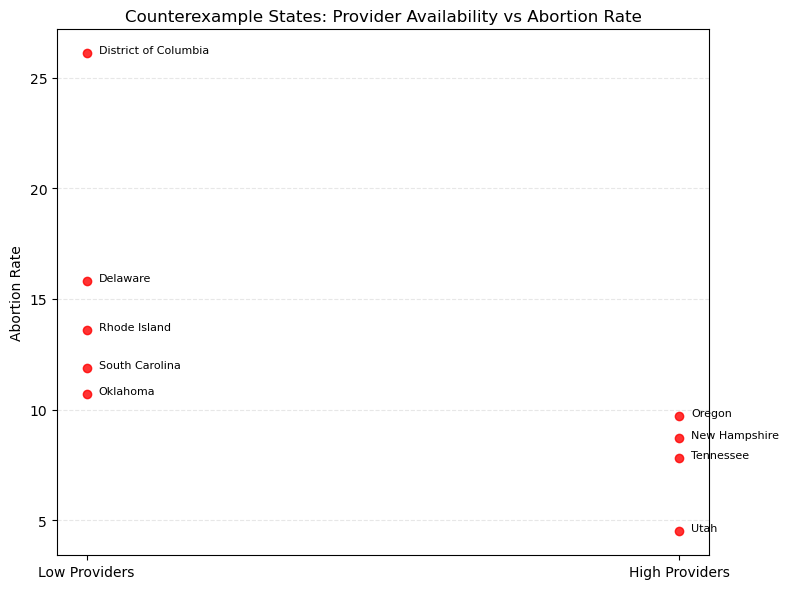

In [ ]:
import matplotlib.pyplot as plt

# === counterexample states ===
df_ce = result_df[result_df['Pattern'] == 'Counterexample'].copy()

# === binary split ===
median_provider = df_ce['Providers'].median()

df_ce['provider_level'] = df_ce['Providers'].apply(
    lambda x: 'Low' if x <= median_provider else 'High'
)

# === plot ===
plt.figure(figsize=(8,6))

# jitter x position
x_positions = df_ce['provider_level'].map({'Low': 0, 'High': 1})

plt.scatter(
    x_positions,
    df_ce['Abortion Rate'],
    color='red',
    alpha=0.8
)

# === add labels ===
for _, row in df_ce.iterrows():
    x = 0 if row['provider_level'] == 'Low' else 1
    plt.text(
        x + 0.02,
        row['Abortion Rate'],
        row['State'],
        fontsize=8
    )

# === axes ===
plt.xticks([0, 1], ['Low Providers', 'High Providers'])
plt.ylabel('Abortion Rate')
plt.title('Counterexample States: Provider Availability vs Abortion Rate')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

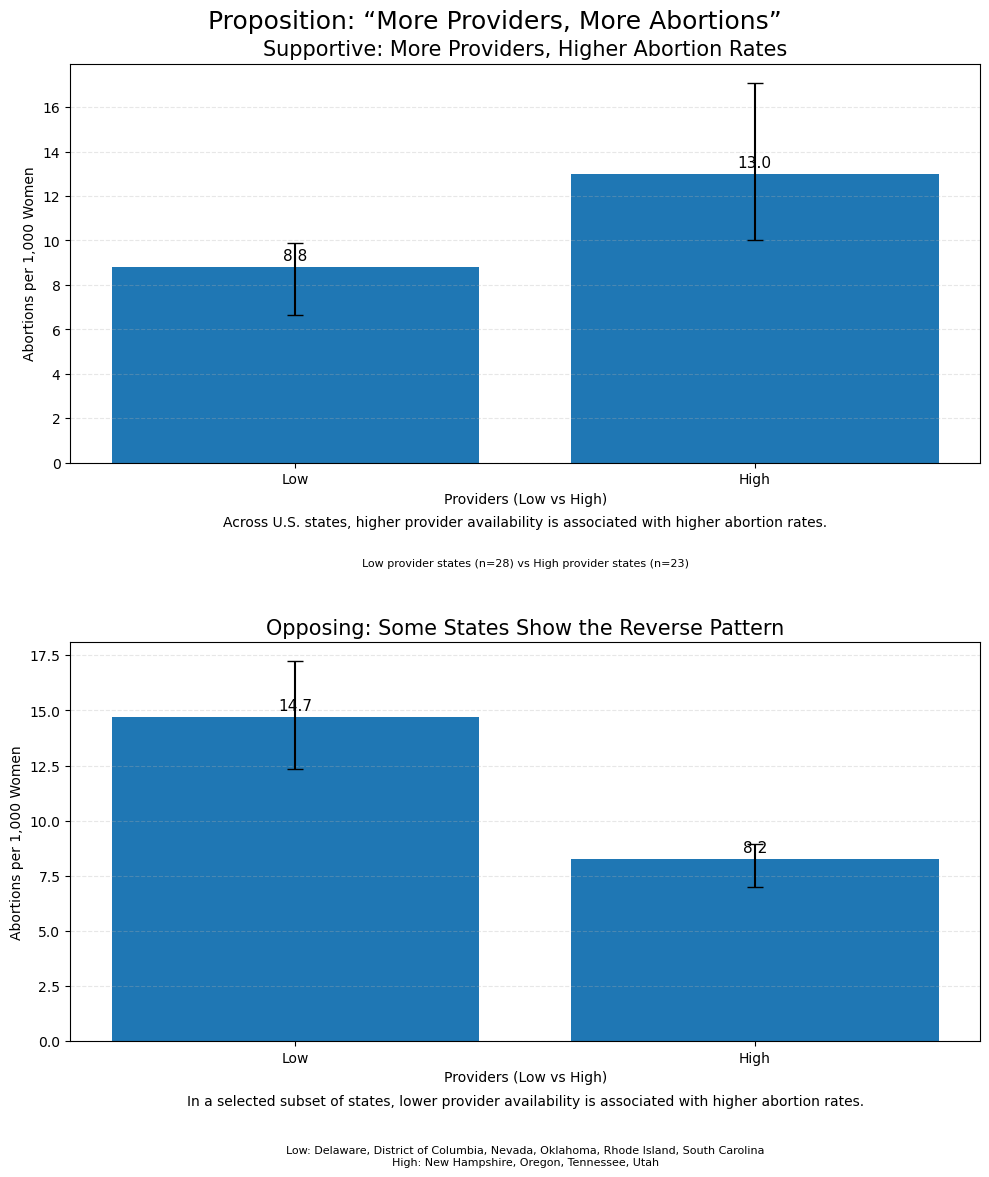

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. read data ===
file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

# =========================================================
# 2. prepare base data
# =========================================================
df_base = df[[
    'U.S. State',
    'No. of abortion providers, 2017',
    'No. of abortions per 1,000 women aged 15–44, by state of residence, 2020'
]].dropna().copy()

df_base.columns = ['state', 'providers', 'abortion_rate']

# nationwide medians
provider_median_all = df_base['providers'].median()
rate_median_all = df_base['abortion_rate'].median()

# =========================================================
# 3. SUPPORTING plot data: all states, low vs high providers
# =========================================================
df_support = df_base.copy()

df_support['provider_level'] = df_support['providers'].apply(
    lambda x: 'Low' if x <= provider_median_all else 'High'
)

summary_support = (
    df_support.groupby('provider_level', observed=False)
    .agg(
        median_rate=('abortion_rate', 'median'),
        q1=('abortion_rate', lambda x: x.quantile(0.25)),
        q3=('abortion_rate', lambda x: x.quantile(0.75)),
        n_states=('state', 'count')
    )
    .reindex(['Low', 'High'])
    .reset_index()
)

yerr_support = np.vstack([
    summary_support['median_rate'] - summary_support['q1'],
    summary_support['q3'] - summary_support['median_rate']
])

support_note = (
    f"Low provider states (n={int(summary_support.loc[summary_support['provider_level']=='Low', 'n_states'].iloc[0])}) "
    f"vs High provider states (n={int(summary_support.loc[summary_support['provider_level']=='High', 'n_states'].iloc[0])})"
)

# =========================================================
# 4. OPPOSING plot data: selected states where pattern differs
# =========================================================
def classify_pattern(row):
    if (row['providers'] > provider_median_all and row['abortion_rate'] < rate_median_all) or \
       (row['providers'] <= provider_median_all and row['abortion_rate'] > rate_median_all):
        return 'Selected'
    return 'Follows Trend'

df_base['pattern'] = df_base.apply(classify_pattern, axis=1)

df_oppose = df_base[df_base['pattern'] == 'Selected'].copy()

# IMPORTANT: still classify low/high using nationwide median
df_oppose['provider_level'] = df_oppose['providers'].apply(
    lambda x: 'Low' if x <= provider_median_all else 'High'
)

summary_oppose = (
    df_oppose.groupby('provider_level', observed=False)
    .agg(
        median_rate=('abortion_rate', 'median'),
        q1=('abortion_rate', lambda x: x.quantile(0.25)),
        q3=('abortion_rate', lambda x: x.quantile(0.75)),
        n_states=('state', 'count')
    )
    .reindex(['Low', 'High'])
    .reset_index()
)

yerr_oppose = np.vstack([
    summary_oppose['median_rate'] - summary_oppose['q1'],
    summary_oppose['q3'] - summary_oppose['median_rate']
])

low_states = df_oppose[df_oppose['provider_level'] == 'Low']['state'].tolist()
high_states = df_oppose[df_oppose['provider_level'] == 'High']['state'].tolist()

oppose_note = (
    f"Low: {', '.join(low_states)}\n"
    f"High: {', '.join(high_states)}"
)

# =========================================================
# 5. stacked plots
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# ---------------- TOP: SUPPORTING ----------------
axes[0].bar(
    summary_support['provider_level'],
    summary_support['median_rate'],
    yerr=yerr_support,
    capsize=6
)

for i, val in enumerate(summary_support['median_rate']):
    axes[0].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=11)

axes[0].set_title('Supportive: More Providers, Higher Abortion Rates', fontsize=15)
axes[0].set_xlabel('Providers (Low vs High)')
axes[0].set_ylabel('Abortions per 1,000 Women')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

axes[0].text(
    0.5, -0.16,
    'Across U.S. states, higher provider availability is associated with higher abortion rates.',
    ha='center',
    transform=axes[0].transAxes,
    fontsize=10
)

axes[0].text(
    0.5, -0.26,
    support_note,
    ha='center',
    transform=axes[0].transAxes,
    fontsize=8
)

# ---------------- BOTTOM: OPPOSING ----------------
axes[1].bar(
    summary_oppose['provider_level'],
    summary_oppose['median_rate'],
    yerr=yerr_oppose,
    capsize=6
)

for i, val in enumerate(summary_oppose['median_rate']):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=11)

axes[1].set_title('Opposing: Some States Show the Reverse Pattern', fontsize=15)
axes[1].set_xlabel('Providers (Low vs High)')
axes[1].set_ylabel('Abortions per 1,000 Women')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

axes[1].text(
    0.5, -0.16,
    'In a selected subset of states, lower provider availability is associated with higher abortion rates.',
    ha='center',
    transform=axes[1].transAxes,
    fontsize=10
)

axes[1].text(
    0.5, -0.31,
    oppose_note,
    ha='center',
    transform=axes[1].transAxes,
    fontsize=8
)

# overall title
fig.suptitle(
    'Proposition: “More Providers, More Abortions”',
    fontsize=18,
    y=0.98
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, bottom=0.12)
plt.show()

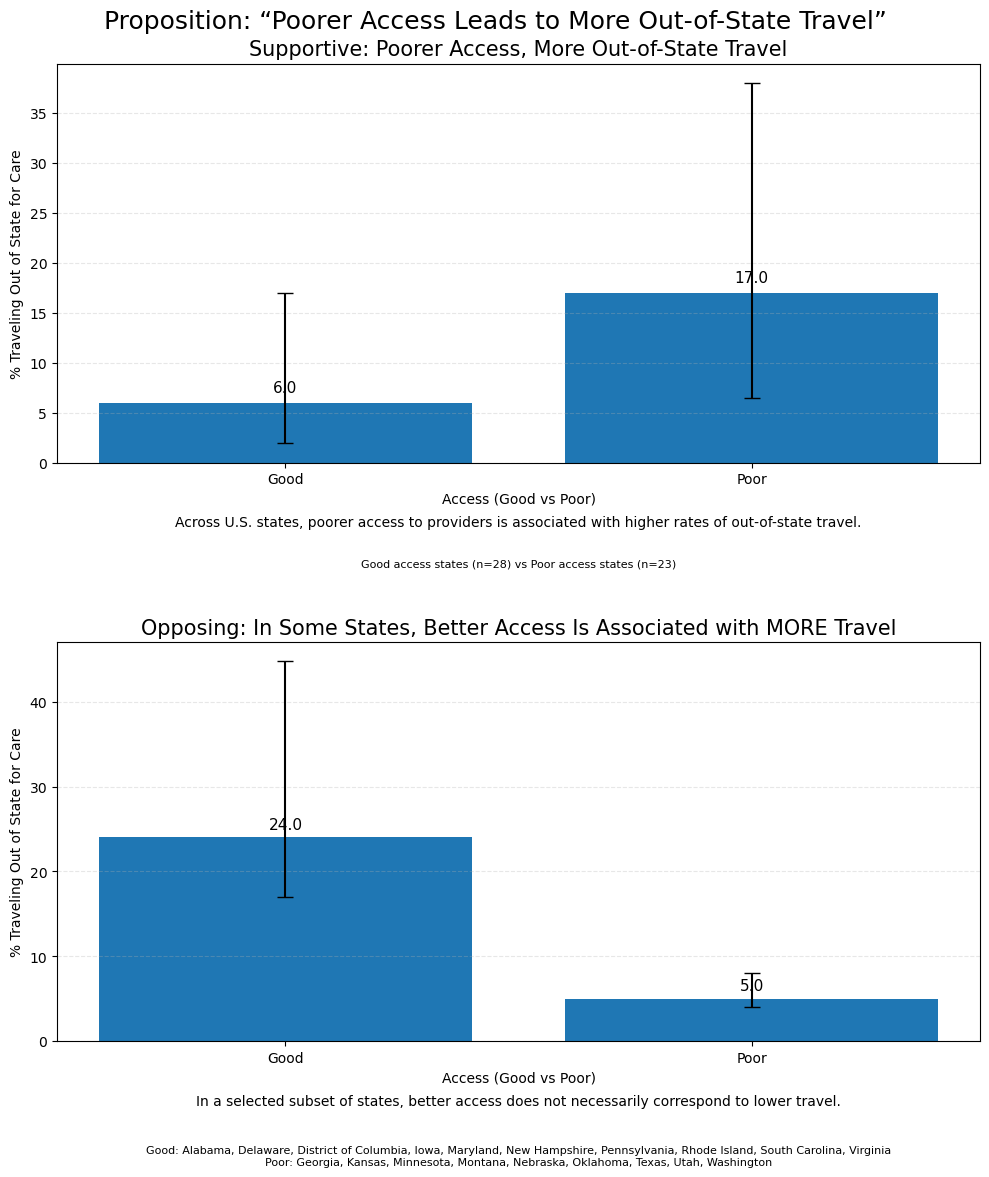

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. read data ===
file_path = r"C:\Users\yhy_s\Desktop\DSC106\project-2\persuasive_deceptive_climate_change\data\GuttmacherInstituteAbortionDataByState.xlsx"
df = pd.read_excel(file_path)

# =========================================================
# 2. prepare base data for access vs travel
# =========================================================
df_base = df[[
    'U.S. State',
    '% of counties without a known abortion provider, 2014',
    '% of residents obtaining abortions who traveled out of state for care, 2020'
]].dropna().copy()

df_base.columns = ['state', 'no_provider_pct', 'travel_pct']

# nationwide medians
access_median_all = df_base['no_provider_pct'].median()
travel_median_all = df_base['travel_pct'].median()

# lower % without provider = better access
df_base['access_level'] = df_base['no_provider_pct'].apply(
    lambda x: 'Good' if x <= access_median_all else 'Poor'
)

# =========================================================
# 3. SUPPORTING plot data: all states, good vs poor access
# =========================================================
summary_support = (
    df_base.groupby('access_level', observed=False)
    .agg(
        median_travel=('travel_pct', 'median'),
        q1=('travel_pct', lambda x: x.quantile(0.25)),
        q3=('travel_pct', lambda x: x.quantile(0.75)),
        n_states=('state', 'count')
    )
    .reindex(['Good', 'Poor'])
    .reset_index()
)

yerr_support = np.vstack([
    summary_support['median_travel'] - summary_support['q1'],
    summary_support['q3'] - summary_support['median_travel']
])

support_note = (
    f"Good access states (n={int(summary_support.loc[summary_support['access_level']=='Good', 'n_states'].iloc[0])}) "
    f"vs Poor access states (n={int(summary_support.loc[summary_support['access_level']=='Poor', 'n_states'].iloc[0])})"
)

# =========================================================
# 4. identify selected states where pattern differs
#    proposition: poorer access -> more travel
#    differing states:
#    Good access + High travel OR Poor access + Low travel
# =========================================================
def classify_pattern(row):
    if (row['no_provider_pct'] <= access_median_all and row['travel_pct'] > travel_median_all) or \
       (row['no_provider_pct'] > access_median_all and row['travel_pct'] <= travel_median_all):
        return 'Selected'
    return 'Follows Trend'

df_base['pattern'] = df_base.apply(classify_pattern, axis=1)

df_oppose = df_base[df_base['pattern'] == 'Selected'].copy()

# IMPORTANT: still classify good/poor using nationwide median
df_oppose['access_level'] = df_oppose['no_provider_pct'].apply(
    lambda x: 'Good' if x <= access_median_all else 'Poor'
)

# =========================================================
# 5. OPPOSING plot data: selected states only
# =========================================================
summary_oppose = (
    df_oppose.groupby('access_level', observed=False)
    .agg(
        median_travel=('travel_pct', 'median'),
        q1=('travel_pct', lambda x: x.quantile(0.25)),
        q3=('travel_pct', lambda x: x.quantile(0.75)),
        n_states=('state', 'count')
    )
    .reindex(['Good', 'Poor'])
    .reset_index()
)

yerr_oppose = np.vstack([
    summary_oppose['median_travel'] - summary_oppose['q1'],
    summary_oppose['q3'] - summary_oppose['median_travel']
])

good_states = df_oppose[df_oppose['access_level'] == 'Good']['state'].tolist()
poor_states = df_oppose[df_oppose['access_level'] == 'Poor']['state'].tolist()

oppose_note = (
    f"Good: {', '.join(good_states)}\n"
    f"Poor: {', '.join(poor_states)}"
)

# =========================================================
# 6. stacked plots
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# ---------------- TOP: SUPPORTING ----------------
axes[0].bar(
    summary_support['access_level'],
    summary_support['median_travel'],
    yerr=yerr_support,
    capsize=6
)

for i, val in enumerate(summary_support['median_travel']):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontsize=11)

axes[0].set_title('Supportive: Poorer Access, More Out-of-State Travel', fontsize=15)
axes[0].set_xlabel('Access (Good vs Poor)')
axes[0].set_ylabel('% Traveling Out of State for Care')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

axes[0].text(
    0.5, -0.16,
    'Across U.S. states, poorer access to providers is associated with higher rates of out-of-state travel.',
    ha='center',
    transform=axes[0].transAxes,
    fontsize=10
)

axes[0].text(
    0.5, -0.26,
    support_note,
    ha='center',
    transform=axes[0].transAxes,
    fontsize=8
)

# ---------------- BOTTOM: OPPOSING ----------------
axes[1].bar(
    summary_oppose['access_level'],
    summary_oppose['median_travel'],
    yerr=yerr_oppose,
    capsize=6
)

for i, val in enumerate(summary_oppose['median_travel']):
    axes[1].text(i, val + 1, f'{val:.1f}', ha='center', fontsize=11)

axes[1].set_title('Opposing: In Some States, Better Access Is Associated with MORE Travel', fontsize=15)
axes[1].set_xlabel('Access (Good vs Poor)')
axes[1].set_ylabel('% Traveling Out of State for Care')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

axes[1].text(
    0.5, -0.16,
    'In a selected subset of states, better access does not necessarily correspond to lower travel.',
    ha='center',
    transform=axes[1].transAxes,
    fontsize=10
)

axes[1].text(
    0.5, -0.31,
    oppose_note,
    ha='center',
    transform=axes[1].transAxes,
    fontsize=8
)

# overall title
fig.suptitle(
    'Proposition: “Poorer Access Leads to More Out-of-State Travel”',
    fontsize=18,
    y=0.98
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, bottom=0.12)
plt.show()